In [184]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [185]:
df = pd.read_csv('california house price dataset.csv')

In [186]:
df

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND


In [187]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [188]:
df.dropna(inplace=True)   

# dropping the null values rows since the data is quite big and the number of null values rows is small so dropping them right option

In [189]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 20433 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20433 non-null  float64
 1   latitude            20433 non-null  float64
 2   housing_median_age  20433 non-null  float64
 3   total_rooms         20433 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20433 non-null  float64
 6   households          20433 non-null  float64
 7   median_income       20433 non-null  float64
 8   median_house_value  20433 non-null  float64
 9   ocean_proximity     20433 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.7+ MB


In [190]:
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20433.000000,20433.000000,20433.000000,20433.000000,20433.000000,20433.000000,20433.000000,20433.000000,20433.000000
mean,-119.570689,35.633221,28.633094,2636.504233,537.870553,1424.946949,499.433465,3.871162,206864.413155
std,2.003578,2.136348,12.591805,2185.269567,421.385070,1133.208490,382.299226,1.899291,115435.667099
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1450.000000,296.000000,787.000000,280.000000,2.563700,119500.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.536500,179700.000000
75%,-118.010000,37.720000,37.000000,3143.000000,647.000000,1722.000000,604.000000,4.744000,264700.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


array([[<Axes: title={'center': 'longitude'}>,
        <Axes: title={'center': 'latitude'}>,
        <Axes: title={'center': 'housing_median_age'}>],
       [<Axes: title={'center': 'total_rooms'}>,
        <Axes: title={'center': 'total_bedrooms'}>,
        <Axes: title={'center': 'population'}>],
       [<Axes: title={'center': 'households'}>,
        <Axes: title={'center': 'median_income'}>,
        <Axes: title={'center': 'median_house_value'}>]], dtype=object)

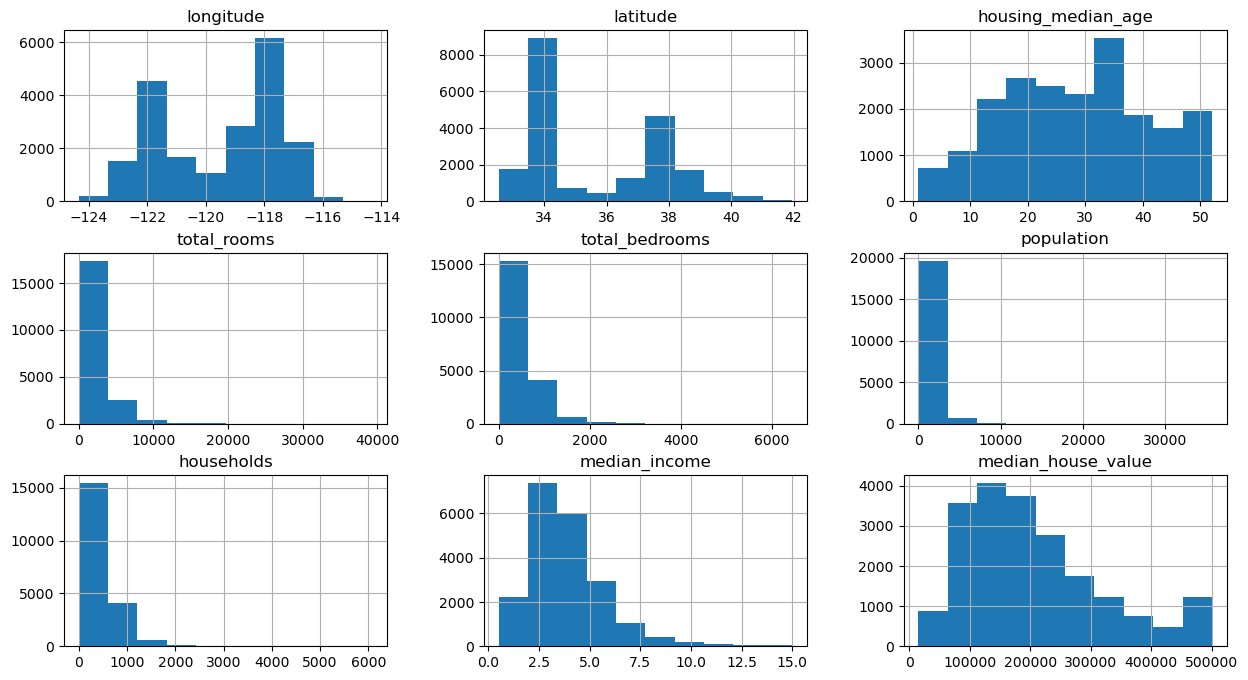

In [191]:
df.hist(figsize=(15,8))

In [192]:
numeric_df = df.select_dtypes(include=[float, int])     
df_corr = numeric_df.corr()  

# here the column ocean proximity is not numeric and correlation only works on numeric data. hence only int and float is used

<Axes: >

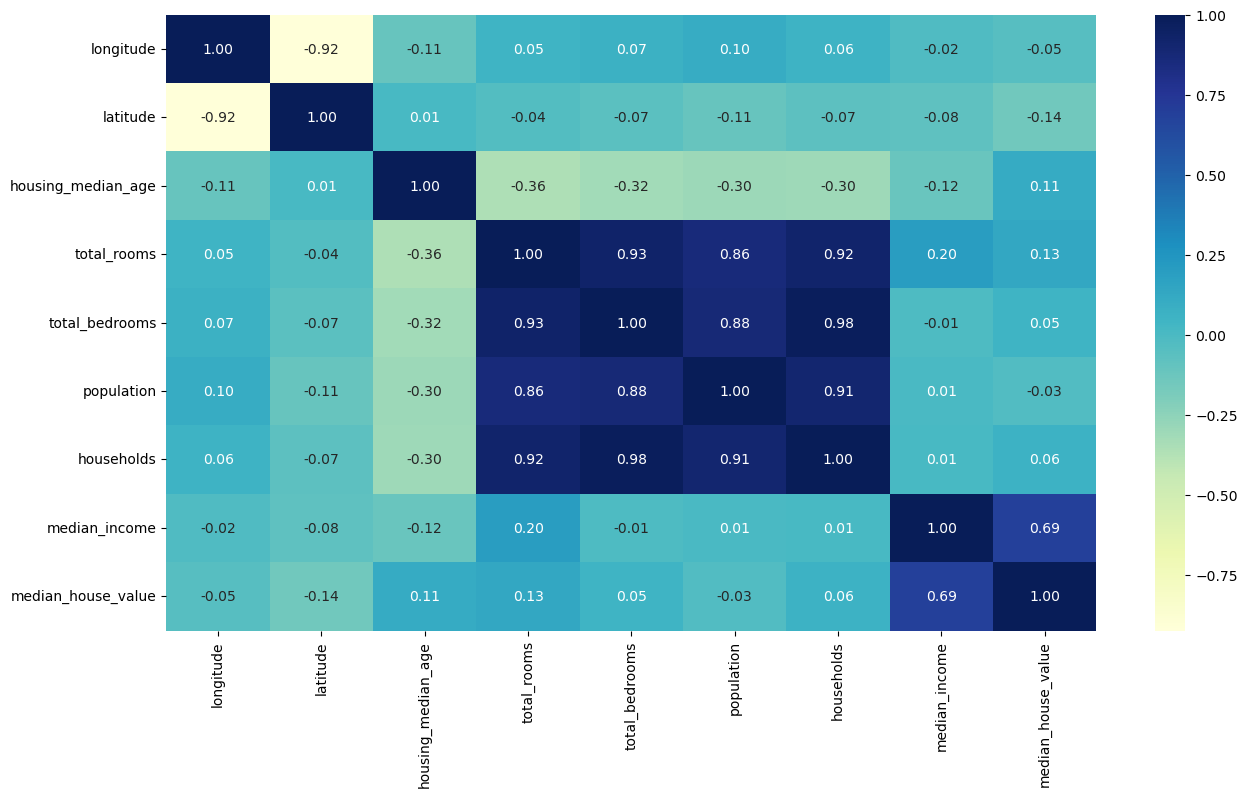

In [193]:
plt.figure(figsize=(15,8))
sns.heatmap(df_corr,annot=True,cmap='YlGnBu',fmt= '.2f')

In [194]:
df['total_rooms'] = np.log(df['total_rooms']+ 1)
df['total_bedrooms'] = np.log(df['total_bedrooms']+1)
df['population'] = np.log(df['population']+1)
df['households'] = np.log(df['households']+1)  

# the reason why we did this is because the 4 columns are right skewed, so to reduce the skewness, we used log transformation and why +1, because if log(0) is there, then it will be undefined.

array([[<Axes: title={'center': 'longitude'}>,
        <Axes: title={'center': 'latitude'}>,
        <Axes: title={'center': 'housing_median_age'}>],
       [<Axes: title={'center': 'total_rooms'}>,
        <Axes: title={'center': 'total_bedrooms'}>,
        <Axes: title={'center': 'population'}>],
       [<Axes: title={'center': 'households'}>,
        <Axes: title={'center': 'median_income'}>,
        <Axes: title={'center': 'median_house_value'}>]], dtype=object)

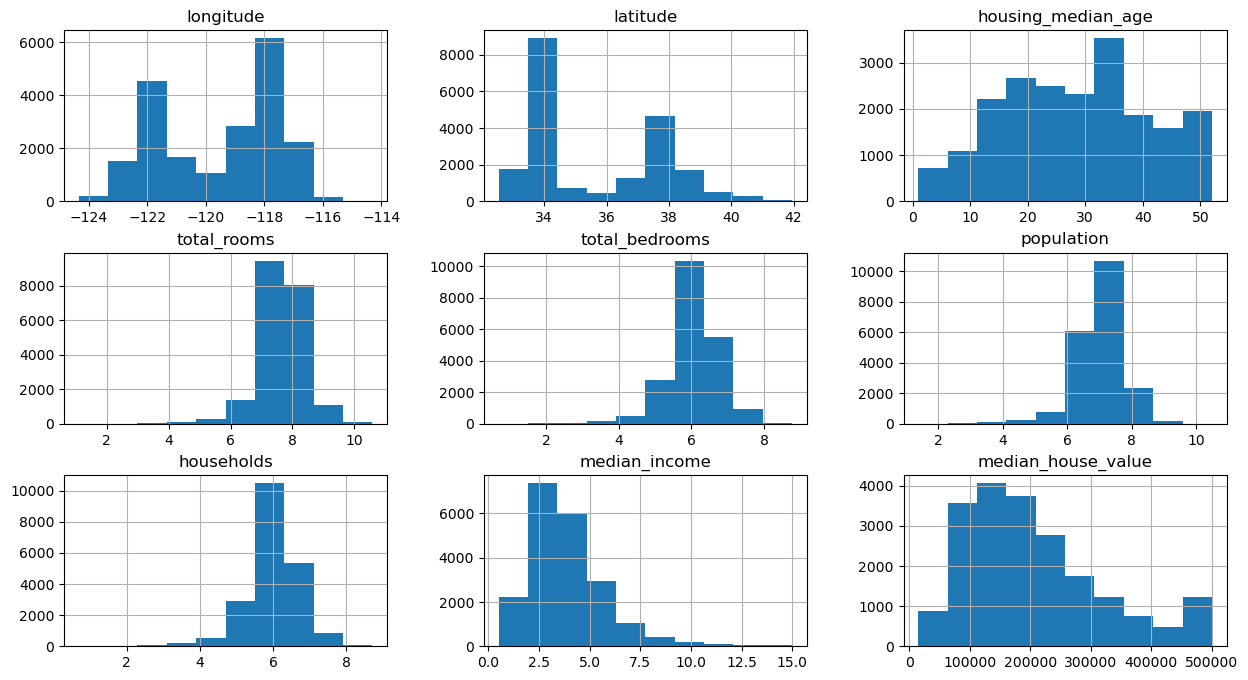

In [195]:
df.hist(figsize=(15,8))    #now we can see that the four columns are kind of normally distributed

In [196]:
df['ocean_proximity'].value_counts()   #this is to understand that how many unique location is there in the dataset.

ocean_proximity
<1H OCEAN     9034
INLAND        6496
NEAR OCEAN    2628
NEAR BAY      2270
ISLAND           5
Name: count, dtype: int64

# now we need to OneHotEncode in the ocean_proximity columns. we can use pandas get_dummies function to onehotencode the ocean_proximity column

In [197]:
df

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,6.781058,4.867534,5.777652,4.844187,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,8.867850,7.009409,7.784057,7.037906,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,7.291656,5.252273,6.208590,5.181784,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,7.150701,5.463832,6.326149,5.393628,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,7.395108,5.638355,6.338594,5.560682,3.8462,342200.0,NEAR BAY
...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,7.418181,5.926926,6.740519,5.802118,1.5603,78100.0,INLAND
20636,-121.21,39.49,18.0,6.548219,5.017280,5.877736,4.744932,2.5568,77100.0,INLAND
20637,-121.22,39.43,17.0,7.720905,6.186209,6.915723,6.073045,1.7000,92300.0,INLAND
20638,-121.32,39.43,18.0,7.528869,6.016157,6.609349,5.857933,1.8672,84700.0,INLAND


In [198]:
# need to use one hot encoding.

In [199]:
from sklearn.preprocessing import OneHotEncoder

In [200]:
ohe = OneHotEncoder()

In [201]:
# Assuming ohe is an instance of OneHotEncoder
encoded = ohe.fit_transform(df['ocean_proximity'].values.reshape(-1, 1))

# Convert the sparse matrix to a dense array
encoded_dense = encoded.toarray()

# Add the encoded features back to the DataFrame as new columns
df_encoded = pd.DataFrame(encoded_dense, columns=ohe.get_feature_names_out(['ocean_proximity']))

# Concatenate the new one-hot encoded columns with the original DataFrame
df = pd.concat([df, df_encoded], axis=1)

In [202]:
df = df.drop('ocean_proximity', axis=1)

In [203]:
df

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,-122.23,37.88,41.0,6.781058,4.867534,5.777652,4.844187,8.3252,452600.0,0.0,0.0,0.0,1.0,0.0
1,-122.22,37.86,21.0,8.867850,7.009409,7.784057,7.037906,8.3014,358500.0,0.0,0.0,0.0,1.0,0.0
2,-122.24,37.85,52.0,7.291656,5.252273,6.208590,5.181784,7.2574,352100.0,0.0,0.0,0.0,1.0,0.0
3,-122.25,37.85,52.0,7.150701,5.463832,6.326149,5.393628,5.6431,341300.0,0.0,0.0,0.0,1.0,0.0
4,-122.25,37.85,52.0,7.395108,5.638355,6.338594,5.560682,3.8462,342200.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20069,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,1.0
20125,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,0.0,0.0,0.0,0.0
20267,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,0.0,0.0,0.0,0.0
20268,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,0.0,0.0,0.0,0.0


In [204]:
df.isnull().sum()

longitude                     205
latitude                      205
housing_median_age            205
total_rooms                   205
total_bedrooms                205
population                    205
households                    205
median_income                 205
median_house_value            205
ocean_proximity_<1H OCEAN     205
ocean_proximity_INLAND        205
ocean_proximity_ISLAND        205
ocean_proximity_NEAR BAY      205
ocean_proximity_NEAR OCEAN    205
dtype: int64

In [205]:
df.dropna(inplace=True)

In [206]:
df

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,-122.23,37.88,41.0,6.781058,4.867534,5.777652,4.844187,8.3252,452600.0,0.0,0.0,0.0,1.0,0.0
1,-122.22,37.86,21.0,8.867850,7.009409,7.784057,7.037906,8.3014,358500.0,0.0,0.0,0.0,1.0,0.0
2,-122.24,37.85,52.0,7.291656,5.252273,6.208590,5.181784,7.2574,352100.0,0.0,0.0,0.0,1.0,0.0
3,-122.25,37.85,52.0,7.150701,5.463832,6.326149,5.393628,5.6431,341300.0,0.0,0.0,0.0,1.0,0.0
4,-122.25,37.85,52.0,7.395108,5.638355,6.338594,5.560682,3.8462,342200.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20428,-118.83,34.23,6.0,9.082961,7.016610,8.127405,6.918695,8.7288,425800.0,0.0,1.0,0.0,0.0,0.0
20429,-118.84,34.22,11.0,8.061802,6.042633,7.257708,6.070738,7.5118,361900.0,0.0,1.0,0.0,0.0,0.0
20430,-118.84,34.21,16.0,8.512382,6.856462,7.839132,6.879356,5.2361,224700.0,0.0,1.0,0.0,0.0,0.0
20431,-118.80,34.21,16.0,7.290975,5.283204,6.495266,5.347108,6.2893,282700.0,0.0,1.0,0.0,0.0,0.0


<Axes: xlabel='latitude', ylabel='longitude'>

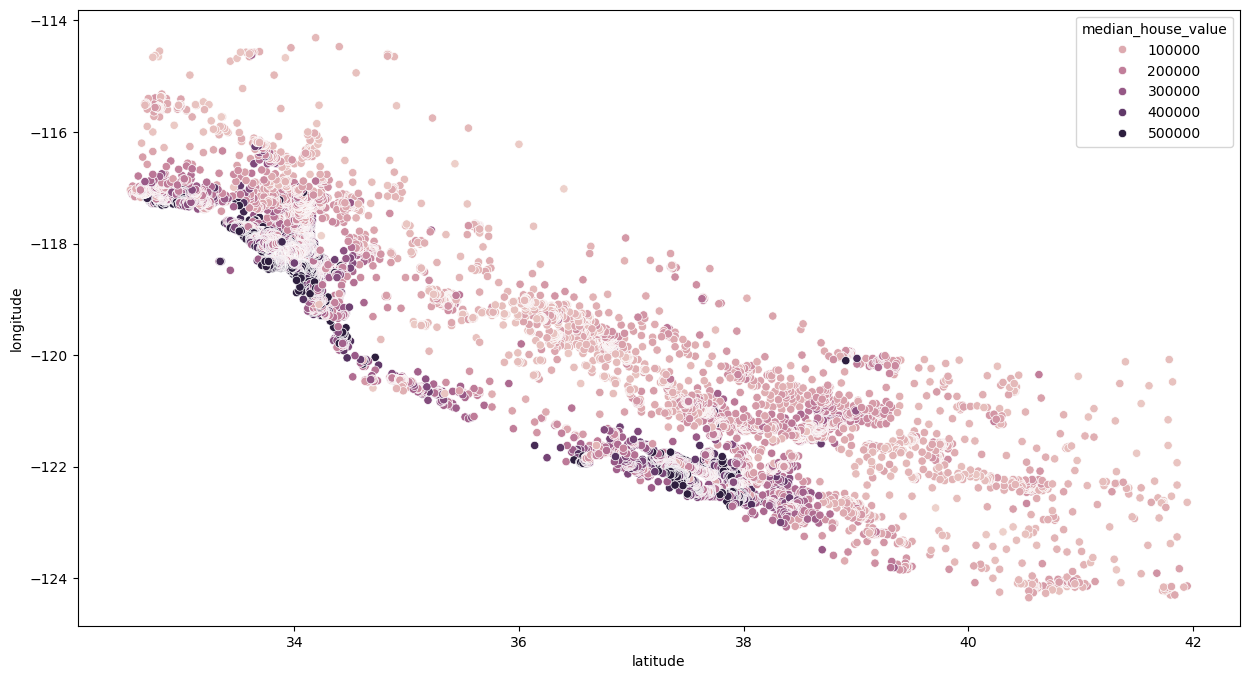

In [207]:
plt.figure(figsize=(15,8))
sns.scatterplot(x=df['latitude'],y=df['longitude'],data=df,hue='median_house_value')

# The heatmap reveals a strong positive correlation between median income and median house value. This relationship is expected, as individuals or households with higher incomes typically have greater purchasing power, enabling them to afford more expensive homes.

In [208]:
df

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,-122.23,37.88,41.0,6.781058,4.867534,5.777652,4.844187,8.3252,452600.0,0.0,0.0,0.0,1.0,0.0
1,-122.22,37.86,21.0,8.867850,7.009409,7.784057,7.037906,8.3014,358500.0,0.0,0.0,0.0,1.0,0.0
2,-122.24,37.85,52.0,7.291656,5.252273,6.208590,5.181784,7.2574,352100.0,0.0,0.0,0.0,1.0,0.0
3,-122.25,37.85,52.0,7.150701,5.463832,6.326149,5.393628,5.6431,341300.0,0.0,0.0,0.0,1.0,0.0
4,-122.25,37.85,52.0,7.395108,5.638355,6.338594,5.560682,3.8462,342200.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20428,-118.83,34.23,6.0,9.082961,7.016610,8.127405,6.918695,8.7288,425800.0,0.0,1.0,0.0,0.0,0.0
20429,-118.84,34.22,11.0,8.061802,6.042633,7.257708,6.070738,7.5118,361900.0,0.0,1.0,0.0,0.0,0.0
20430,-118.84,34.21,16.0,8.512382,6.856462,7.839132,6.879356,5.2361,224700.0,0.0,1.0,0.0,0.0,0.0
20431,-118.80,34.21,16.0,7.290975,5.283204,6.495266,5.347108,6.2893,282700.0,0.0,1.0,0.0,0.0,0.0


# now one more aspect in this data is that here, the total number of bedrooms and the total number of rooms is the collective number of rooms in the particular block, meaning this is the total number of bedrooms in a particular block of rooms

In [209]:
df['bedroom'] = df['total_bedrooms']/df['total_rooms']

In [210]:
df

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN,bedroom
0,-122.23,37.88,41.0,6.781058,4.867534,5.777652,4.844187,8.3252,452600.0,0.0,0.0,0.0,1.0,0.0,0.717813
1,-122.22,37.86,21.0,8.867850,7.009409,7.784057,7.037906,8.3014,358500.0,0.0,0.0,0.0,1.0,0.0,0.790429
2,-122.24,37.85,52.0,7.291656,5.252273,6.208590,5.181784,7.2574,352100.0,0.0,0.0,0.0,1.0,0.0,0.720313
3,-122.25,37.85,52.0,7.150701,5.463832,6.326149,5.393628,5.6431,341300.0,0.0,0.0,0.0,1.0,0.0,0.764097
4,-122.25,37.85,52.0,7.395108,5.638355,6.338594,5.560682,3.8462,342200.0,0.0,0.0,0.0,1.0,0.0,0.762444
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20428,-118.83,34.23,6.0,9.082961,7.016610,8.127405,6.918695,8.7288,425800.0,0.0,1.0,0.0,0.0,0.0,0.772502
20429,-118.84,34.22,11.0,8.061802,6.042633,7.257708,6.070738,7.5118,361900.0,0.0,1.0,0.0,0.0,0.0,0.749539
20430,-118.84,34.21,16.0,8.512382,6.856462,7.839132,6.879356,5.2361,224700.0,0.0,1.0,0.0,0.0,0.0,0.805469
20431,-118.80,34.21,16.0,7.290975,5.283204,6.495266,5.347108,6.2893,282700.0,0.0,1.0,0.0,0.0,0.0,0.724622


In [211]:
df['rooms'] = df['total_rooms']/df['households']

In [212]:
df

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN,bedroom,rooms
0,-122.23,37.88,41.0,6.781058,4.867534,5.777652,4.844187,8.3252,452600.0,0.0,0.0,0.0,1.0,0.0,0.717813,1.399834
1,-122.22,37.86,21.0,8.867850,7.009409,7.784057,7.037906,8.3014,358500.0,0.0,0.0,0.0,1.0,0.0,0.790429,1.260013
2,-122.24,37.85,52.0,7.291656,5.252273,6.208590,5.181784,7.2574,352100.0,0.0,0.0,0.0,1.0,0.0,0.720313,1.407171
3,-122.25,37.85,52.0,7.150701,5.463832,6.326149,5.393628,5.6431,341300.0,0.0,0.0,0.0,1.0,0.0,0.764097,1.325768
4,-122.25,37.85,52.0,7.395108,5.638355,6.338594,5.560682,3.8462,342200.0,0.0,0.0,0.0,1.0,0.0,0.762444,1.329892
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20428,-118.83,34.23,6.0,9.082961,7.016610,8.127405,6.918695,8.7288,425800.0,0.0,1.0,0.0,0.0,0.0,0.772502,1.312814
20429,-118.84,34.22,11.0,8.061802,6.042633,7.257708,6.070738,7.5118,361900.0,0.0,1.0,0.0,0.0,0.0,0.749539,1.327977
20430,-118.84,34.21,16.0,8.512382,6.856462,7.839132,6.879356,5.2361,224700.0,0.0,1.0,0.0,0.0,0.0,0.805469,1.237381
20431,-118.80,34.21,16.0,7.290975,5.283204,6.495266,5.347108,6.2893,282700.0,0.0,1.0,0.0,0.0,0.0,0.724622,1.363536


<Axes: >

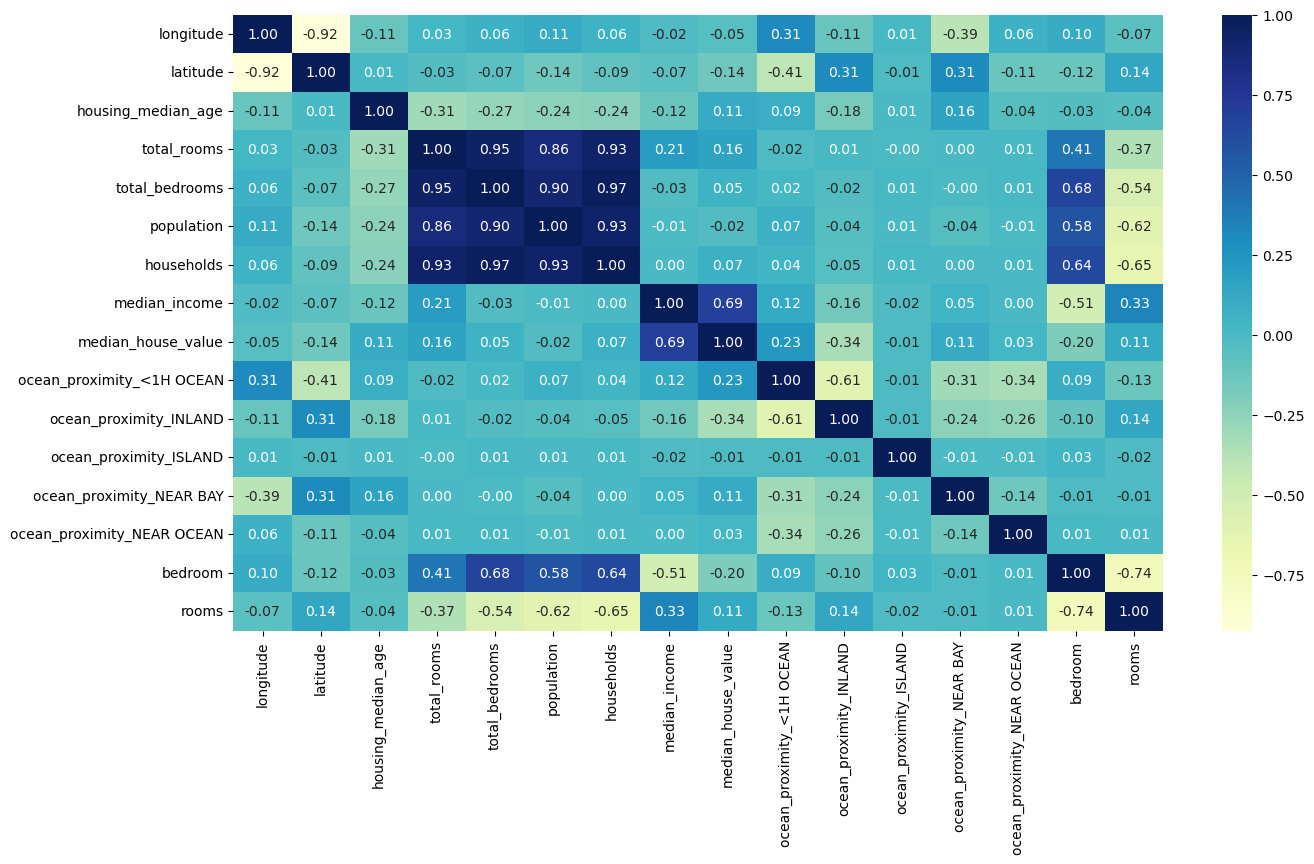

In [213]:
plt.figure(figsize=(15,8))
numeric_df = df.select_dtypes(include='number')
sns.heatmap(numeric_df.corr(), annot=True, cmap='YlGnBu', fmt='.2f')

In [214]:
from sklearn.model_selection import train_test_split

In [215]:
X= df.drop(['median_house_value'],axis=1)
y= df['median_house_value']

In [216]:
X_train,X_test,y_train, y_test = train_test_split(X,y,test_size=0.2)

# lets create a model using linear regression and RandomForestRegressor

In [217]:
from sklearn.linear_model import LinearRegression

In [218]:
lr = LinearRegression()

In [219]:
lr.fit(X_train,y_train)

LinearRegression()

In [220]:
X_train

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN,bedroom,rooms
433,-122.29,37.88,46.0,7.547502,6.093570,6.825460,6.054439,2.9926,0.0,0.0,0.0,1.0,0.0,0.807362,1.246606
3749,-118.38,34.18,40.0,7.640123,6.343880,7.242082,6.267201,3.0061,1.0,0.0,0.0,0.0,0.0,0.830337,1.219065
14808,-117.18,32.69,37.0,8.043342,6.575076,7.173958,6.514713,3.2121,1.0,0.0,0.0,0.0,0.0,0.817456,1.234643
2004,-119.79,36.74,52.0,5.159055,4.477337,5.996452,4.442651,2.1094,0.0,1.0,0.0,0.0,0.0,0.867860,1.161256
7892,-118.07,33.88,18.0,7.798523,5.929589,7.173192,5.958425,6.1968,1.0,0.0,0.0,0.0,0.0,0.760348,1.308823
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7441,-118.20,33.94,45.0,7.359468,5.796058,7.186901,5.707110,3.7361,1.0,0.0,0.0,0.0,0.0,0.787565,1.289526
15638,-122.41,37.79,52.0,8.188411,6.919684,7.631917,6.874198,2.9871,0.0,0.0,0.0,1.0,0.0,0.845058,1.191181
9903,-122.26,38.31,33.0,8.416046,6.558198,7.482682,6.507278,5.2444,0.0,1.0,0.0,0.0,0.0,0.779249,1.293328
16696,-120.62,35.11,18.0,7.715124,6.300786,7.327781,6.234411,2.0292,0.0,0.0,0.0,0.0,1.0,0.816680,1.237506


In [109]:
lr.score(X_test,y_test)  #this is the accuracy before doing any hyperparameter tuning

0.6822075968071031

In [221]:
y_pred = lr.predict(X_test)

In [222]:
# R² Score
r2 = r2_score(y_test, y_pred)

# Mean Absolute Error
mae = mean_absolute_error(y_test, y_pred)

# Mean Squared Error
mse = mean_squared_error(y_test, y_pred)

# Root Mean Squared Error
rmse = np.sqrt(mse)

print(f"R² Score: {r2:.4f}")
print(f"MAE: {mae:.2f}")
print(f"MSE: {mse:.2f}")
print(f"RMSE: {rmse:.2f}")

R² Score: 0.6829
MAE: 46835.53
MSE: 4147452622.06
RMSE: 64400.72


In [110]:
#we can do standardscaler in the data to improve our model

In [223]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train_scaler = scaler.fit_transform(X_train)
X_test_scaler = scaler.transform(X_test)

In [224]:
lr.fit(X_train_scaler,y_train)

LinearRegression()

In [225]:
lr.score(X_test_scaler,y_test)    #slightly better results but using RandomForestRegressor the results will be better.

0.6828978191703012

In [226]:
y_pred1 = lr.predict(X_test_scaler)

In [227]:
# R² Score
r2 = r2_score(y_test, y_pred1)

# Mean Absolute Error
mae = mean_absolute_error(y_test, y_pred1)

# Mean Squared Error
mse = mean_squared_error(y_test, y_pred1)

# Root Mean Squared Error
rmse = np.sqrt(mse)

print(f"R² Score: {r2:.4f}")
print(f"MAE: {mae:.2f}")
print(f"MSE: {mse:.2f}")
print(f"RMSE: {rmse:.2f}")


R² Score: 0.6829
MAE: 46835.53
MSE: 4147452622.06
RMSE: 64400.72


In [228]:
from sklearn.ensemble import RandomForestRegressor

In [229]:
rf = RandomForestRegressor()

In [230]:
rf.fit(X_train,y_train)

RandomForestRegressor()

In [231]:
rf.score(X_test,y_test)  #we can see that the results are better than linear regression

0.8066113848630451

In [233]:
y_pred2 = rf.predict(X_test)

In [234]:
# R² Score
r2 = r2_score(y_test, y_pred2)

# Mean Absolute Error
mae = mean_absolute_error(y_test, y_pred2)

# Mean Squared Error
mse = mean_squared_error(y_test, y_pred2)

# Root Mean Squared Error
rmse = np.sqrt(mse)

print(f"R² Score: {r2:.4f}")
print(f"MAE: {mae:.2f}")
print(f"MSE: {mse:.2f}")
print(f"RMSE: {rmse:.2f}")


R² Score: 0.8066
MAE: 32844.84
MSE: 2529374338.67
RMSE: 50292.89


In [235]:
# let's use GridSearchCV

In [248]:
from sklearn.model_selection import GridSearchCV

In [249]:
rf = RandomForestRegressor()

In [250]:
param_grid = {
    'n_estimators' : [100,150,200],
    'min_samples_split':[2,4],
    'max_depth' :[None, 4,6]
}
grid_search = GridSearchCV(rf, param_grid, cv =2,
                           scoring = 'neg_mean_squared_error',
                           return_train_score = True)
grid_search.fit(X_train,y_train)

GridSearchCV(cv=2, estimator=RandomForestRegressor(),
             param_grid={'max_depth': [None, 4, 6], 'min_samples_split': [2, 4],
                         'n_estimators': [100, 150, 200]},
             return_train_score=True, scoring='neg_mean_squared_error')

In [251]:
print("Best estimator: ", grid_search.best_estimator_)

Best estimator:  RandomForestRegressor(n_estimators=150)


In [252]:
print("Best estimator: ", grid_search.best_params_)

Best estimator:  {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 150}


In [253]:
rf1 = RandomForestRegressor(max_depth = None, min_samples_split = 2, n_estimators = 150)

In [254]:
rf1.fit(X_train,y_train)

RandomForestRegressor(n_estimators=150)

In [255]:
rf1.score(X_test,y_test)

0.808889155363113

In [256]:
y_pred3 = rf1.predict(X_test)

In [257]:
# R² Score
r2 = r2_score(y_test, y_pred3)

# Mean Absolute Error
mae = mean_absolute_error(y_test, y_pred3)

# Mean Squared Error
mse = mean_squared_error(y_test, y_pred3)

# Root Mean Squared Error
rmse = np.sqrt(mse)

print(f"R² Score: {r2:.4f}")
print(f"MAE: {mae:.2f}")
print(f"MSE: {mse:.2f}")
print(f"RMSE: {rmse:.2f}")


R² Score: 0.8089
MAE: 32711.51
MSE: 2499582852.51
RMSE: 49995.83


# the reason why the other metrics such as R2 score, MAE, MSE, and RMSE were used is that 
R² Score: Measures how well the model explains the variability in the target variable — higher is better.

MAE: Shows the average absolute difference between actual and predicted values — lower is better.

MSE: Emphasizes larger errors by squaring them — useful for detecting big mistakes.

RMSE: Provides error in original units while penalizing large errors — helps understand model performance clearly.